# Wiggly circle example



### Setup

Say we have $r=1+b/a \sin(a \theta), \theta \in [0,2\pi], a \in \mathbb{Z} \setminus 1, b \in \mathbb{R}^+$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
from scipy.ndimage import gaussian_filter1d

def compute_exact_density_and_mode(a, sigma, b=1, phase=0.0, grid_res=500, num_theta=200, num_rays=500):
    theta     = np.linspace(0, 2 * np.pi, num_theta)
    r_true    = 1 + (b / a) * np.sin(a * theta + phase)
    dr_dtheta = np.cos(a * theta + phase)

    x_c = r_true * np.cos(theta)
    y_c = r_true * np.sin(theta)

    ds = np.sqrt(r_true**2 + dr_dtheta**2)
    total_arc_length = np.trapezoid(ds, x=theta)

    limit = 2.0
    x_span = np.linspace(-limit, limit, grid_res)
    y_span = np.linspace(-limit, limit, grid_res)
    X, Y = np.meshgrid(x_span, y_span)

    density_grid = np.zeros_like(X)
    for i in range(grid_res):
        X_row = X[i, :][..., np.newaxis]
        Y_row = Y[i, :][..., np.newaxis]
        sq_dist = (X_row - x_c)**2 + (Y_row - y_c)**2
        integrand = np.exp(-sq_dist / (2 * sigma**2)) * ds
        density_grid[i, :] = np.trapezoid(integrand, x=theta, axis=-1) / (2 * np.pi * sigma**2 * total_arc_length)

    phi    = np.linspace(0, 2 * np.pi, num_rays)
    R_span = np.linspace(0, limit * 0.95, grid_res)
    PHI, R_grid = np.meshgrid(phi, R_span)
    X_ray = R_grid * np.cos(PHI)
    Y_ray = R_grid * np.sin(PHI)

    density_ray = np.zeros_like(X_ray)
    for i in range(grid_res):
        X_r_row = X_ray[i, :][..., np.newaxis]
        Y_r_row = Y_ray[i, :][..., np.newaxis]
        sq_dist_ray = (X_r_row - x_c)**2 + (Y_r_row - y_c)**2
        integrand_ray = np.exp(-sq_dist_ray / (2 * sigma**2)) * ds
        density_ray[i, :] = np.trapezoid(integrand_ray, x=theta, axis=-1)

    idx_c = np.clip(np.argmax(density_ray, axis=0), 1, grid_res - 2)
    j = np.arange(num_rays)
    y0_, y1_, y2_ = density_ray[idx_c - 1, j], density_ray[idx_c, j], density_ray[idx_c + 1, j]
    denom  = y0_ - 2 * y1_ + y2_
    offset = np.where(np.abs(denom) > 1e-30, 0.5 * (y0_ - y2_) / denom, 0.0)
    R_mode = R_span[idx_c] + offset * (R_span[1] - R_span[0])
    R_mode = gaussian_filter1d(R_mode, sigma=num_rays / 200, mode='wrap')

    x_mode = R_mode * np.cos(phi)
    y_mode = R_mode * np.sin(phi)

    return X, Y, density_grid, x_c, y_c, x_mode, y_mode


def plot_density(a=8, b=1, sigma=0.10, x_coord=0.0, y_coord=0.0):
    X, Y, exact_density, x_true, y_true, x_mode, y_mode = compute_exact_density_and_mode(a, sigma, b)

    fig, ax = plt.subplots(figsize=(8, 8))
    cm = ax.pcolormesh(X, Y, exact_density, shading='auto', cmap='viridis')
    plt.colorbar(cm, ax=ax, label=r'$p_\sigma(x,y)$')
    ax.plot(x_true, y_true, color='black', linewidth=1.5, label='True curve $C$')
    ax.plot(np.append(x_mode, x_mode[0]), np.append(y_mode, y_mode[0]),
            color='red', linewidth=2.0, label='Mode curve $M$')
    ax.scatter(x_coord, y_coord, color='orange', marker='.', s=100, linewidth=2,
               label=f'Point ({x_coord:.1f}, {y_coord:.1f})')
    ax.set_aspect('equal')
    ax.set_title(rf'Exact density — $a={a}$, $\sigma={sigma:.2f}$, $b = {b:.2f}$', fontsize=12)
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.legend(loc='upper right')
    plt.show()


interact(
    plot_density,
    a=IntSlider(value=8, min=2, max=16, step=1, description='a'),
    b=FloatSlider(value=1, min=0, max=2.0, step=0.1, description='b'),
    sigma=FloatSlider(value=0.10, min=0.01, max=0.7, step=0.01, description='σ', readout_format='.2f'),
    x_coord=FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1, description='x'),
    y_coord=FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1, description='y'),
)

interactive(children=(IntSlider(value=8, description='a', max=16, min=2), FloatSlider(value=1.0, description='…

<function __main__.plot_density(a=8, b=1, sigma=0.1, x_coord=0.0, y_coord=0.0)>

## Recap on mathematics
### System Setup and Definitions

Let $y \in \mathbb{R}^d$ be a random variable distributed according to an arbitrary data distribution $p(y)$. Let $x \in \mathbb{R}^d$ be the corresponding noise-perturbed variable generated via the conditional distribution:

$$p_\sigma(x|y) = \mathcal{N}(x; y, \sigma^2 I_d) = \frac{1}{(2\pi\sigma^2)^{d/2}} \exp\left( -\frac{\|x - y\|^2}{2\sigma^2} \right)$$

The marginal distribution $p_\sigma(x)$ is defined by the convolution:

$$p_\sigma(x) = \int_{\mathbb{R}^d} p(y) p_\sigma(x|y) \, dy$$

By Bayes' theorem, the posterior distribution of the clean data $y$ given the observed noisy vector $x$ is:

$$p_\sigma(y|x) = \frac{p(y) p_\sigma(x|y)}{p_\sigma(x)}$$


### Jacobian of score function

$$\nabla_x^2 \log p_\sigma(x) = \frac{1}{\sigma^4} \operatorname{Cov}_{y \sim p_\sigma(y|x)}(y) - \frac{1}{\sigma^2} I_d$$

where $\operatorname{Cov}_{y \sim p_\sigma(y|x)}(y) \in \mathbb{R}^{d \times d}$ is the conditional covariance matrix of the clean data given the noisy observation:

$$\operatorname{Cov}_{y \sim p_\sigma(y|x)}(y) = \mathbb{E}_{y \sim p_\sigma(y|x)}\left[ y y^T \right] - \mathbb{E}_{y \sim p_\sigma(y|x)}[y] \mathbb{E}_{y \sim p_\sigma(y|x)}[y]^T$$


### First-Order Derivative (The Score Function)
We begin by evaluating the spatial gradient of the log-marginal density:

$$\text{score}(x) = \nabla_x \log p_\sigma(x) = \frac{\nabla_x p_\sigma(x)}{p_\sigma(x)}$$

Differentiating the convolution integral under the integral sign yields:

$$\nabla_x p_\sigma(x) = \int_{\mathbb{R}^d} p(y) \nabla_x p_\sigma(x|y) \, dy$$

The gradient of the Gaussian kernel with respect to $x$ is:

$$\nabla_x p_\sigma(x|y) = p_\sigma(x|y) \left( \frac{y - x}{\sigma^2} \right)$$

Substituting this back into the gradient equation and normalizing by $p_\sigma(x)$ provides:

$$\begin{aligned}
\nabla_x \log p_\sigma(x) &= \int_{\mathbb{R}^d} \frac{p(y) p_\sigma(x|y)}{p_\sigma(x)} \left( \frac{y - x}{\sigma^2} \right) \, dy \\
&= \int_{\mathbb{R}^d} p_\sigma(y|x) \left( \frac{y - x}{\sigma^2} \right) \, dy \\
&= \frac{\mathbb{E}_{y \sim p_\sigma(y|x)}[y] - x}{\sigma^2}
\end{aligned}$$

> **Tweedie's Formula:**
> $$\nabla_x \log p_\sigma(x) = \frac{\mathbb{E}_{y \sim p_\sigma(y|x)}[y] - x}{\sigma^2}$$


In [2]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import VBox, HBox

def compute_local_properties(x0, y0, a, sigma, b=1, phase=0.0, num_theta=1000):
    theta = np.linspace(0, 2 * np.pi, num_theta)
    r_true = 1 + (b / a) * np.sin(a * theta + phase)
    x_c = r_true * np.cos(theta)
    y_c = r_true * np.sin(theta)

    dist_sq = (x_c - x0)**2 + (y_c - y0)**2
    weights = np.exp(-dist_sq / (2 * sigma**2))
    weights /= np.sum(weights)

    y_mean = np.array([np.sum(weights * x_c), np.sum(weights * y_c)])
    score_raw = (y_mean - np.array([x0, y0])) / (sigma**2)
    score_mag = np.linalg.norm(score_raw)
    score_unit = score_raw / score_mag if score_mag > 1e-9 else score_raw

    E_yyT = np.array([[np.sum(weights * x_c**2), np.sum(weights * x_c * y_c)],
                      [np.sum(weights * x_c * y_c), np.sum(weights * y_c**2)]])
    cov = E_yyT - np.outer(y_mean, y_mean)
    jacobian = (1 / sigma**4) * cov - (1 / sigma**2) * np.eye(2)
    eigenvalues, eigenvectors = np.linalg.eigh(jacobian)

    return score_raw, score_unit, eigenvectors, eigenvalues


state = {'x': 0.25, 'y': 1.2}

a_slider     = widgets.IntSlider(  value=8,   min=2,    max=16,    step=1,       description='a')
sigma_slider = widgets.FloatSlider(value=0.2, min=0.01, max=0.7,     step=0.01,      description='σ')
b_slider     = widgets.FloatSlider(value=1, min=0, max=2,     step=0.01,      description='b')
phase_slider = widgets.FloatSlider(value=0.0, min=0.0,  max=2*np.pi, step=np.pi/100, description='φ')

fig, ax = plt.subplots(figsize=(9, 9))
fig.canvas.toolbar_visible = False

def inv_max_curvature_curve(x, y):
    dx  = np.gradient(x);  dy  = np.gradient(y)
    ddx = np.gradient(dx); ddy = np.gradient(dy)
    kappa = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5
    return 1.0 / np.max(kappa)

def inv_max_curvature_polar(a, b, phase, num_theta=5000):
    theta = np.linspace(0, 2 * np.pi, num_theta)
    r   =  1 + (b / a) * np.sin(a * theta + phase)
    dr  =  np.cos(a * theta + phase)
    ddr = -a * np.sin(a * theta + phase)
    kappa = np.abs(r**2 + 2*dr**2 - r*ddr) / (r**2 + dr**2)**1.5
    return 1.0 / np.max(kappa)

def redraw():
    a     = a_slider.value
    b     = b_slider.value
    sigma = sigma_slider.value
    phase = phase_slider.value
    x0, y0 = state['x'], state['y']

    # Note: Ensure compute_exact_density_and_mode is defined in your environment
    X, Y, exact_density, x_true, y_true, x_mode, y_mode = compute_exact_density_and_mode(
        a, sigma, b, phase=phase, num_rays=2000)
    score, score_unit, eigvecs, eigvals = compute_local_properties(x0, y0, a, sigma, b, phase=phase)

    for i in range(2):
        if np.dot(eigvecs[:, i], score_unit) < 0:
            eigvecs[:, i] *= -1

    ax.cla()
    ax.pcolormesh(X, Y, exact_density, shading='auto', cmap='viridis', alpha=0.5)
    ax.plot(x_true, y_true, color='black', linewidth=1, label='True curve $C$')
    ax.plot(np.append(x_mode, x_mode[0]), np.append(y_mode, y_mode[0]),
            color='red', linewidth=2, label='Mode curve $M$')

    L = 0.3

    def unit_toward(tx, ty):
        v = np.array([tx - x0, ty - y0])
        n = np.linalg.norm(v)
        return v / n if n > 1e-9 else v

    idx_true = np.argmin((x_true - x0)**2 + (y_true - y0)**2)
    d_true = unit_toward(x_true[idx_true], y_true[idx_true])
    ax.annotate("", xy=(x0 + L * d_true[0], y0 + L * d_true[1]), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='black', alpha=0.5, lw=2), zorder=5)

    idx_mode = np.argmin((x_mode - x0)**2 + (y_mode - y0)**2)
    d_mode = unit_toward(x_mode[idx_mode], y_mode[idx_mode])
    ax.annotate("", xy=(x0 + L * d_mode[0], y0 + L * d_mode[1]), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.5, lw=2), zorder=5)

    ax.quiver(x0, y0, score_unit[0], score_unit[1], color='white', alpha=1,
              scale=1/L, scale_units='xy', label='Score Dir', zorder=3)
    ax.quiver(x0, y0, eigvecs[0, 0], eigvecs[1, 0], color='cyan', alpha=0.5,
              scale=1/L, scale_units='xy', label='Eig1 Dir', zorder=4)
    ax.quiver(x0, y0, eigvecs[0, 1], eigvecs[1, 1], color='magenta', alpha=0.5,
              scale=1/L, scale_units='xy', label='Eig2 Dir', zorder=4)

    roc_true = inv_max_curvature_polar(a, b, phase)
    roc_mode = inv_max_curvature_curve(x_mode, y_mode)

    ax.set_aspect('equal')
    ax.set_title(
        f"Score Mag: {np.linalg.norm(score):.2f} | λ₁: {eigvals[0]:.2f}, λ₂: {eigvals[1]:.2f}\n"
        f"1/κ_max — true: {roc_true:.3f}  mode: {roc_mode:.3f}"
    )
    ax.legend(loc='upper right', frameon=True)
    fig.canvas.draw_idle()


def on_click(event):
    if event.inaxes == ax:
        state['x'], state['y'] = event.xdata, event.ydata
        redraw()

fig.canvas.mpl_connect('button_press_event', on_click)

# Added b_slider to the observer loop
for sl in [a_slider, sigma_slider, b_slider, phase_slider]:
    sl.observe(lambda _: redraw(), names='value')

# Added b_slider to HBox for layout display
display(VBox([HBox([a_slider, sigma_slider, b_slider, phase_slider]), fig.canvas]))
redraw()

In [2]:
import numpy as np
from scipy.ndimage import gaussian_filter1d


def _wiggly_circle(a, phase, b, num_theta=1000):
    theta = np.linspace(0, 2 * np.pi, num_theta)
    r   = 1 + (b / a) * np.sin(a * theta + phase)
    dr  = b * np.cos(a * theta + phase)
    x_c = r * np.cos(theta)
    y_c = r * np.sin(theta)
    ds  = np.sqrt(r**2 + dr**2)
    return theta, x_c, y_c, ds


def _compute_mode_curve(a, sigma, phase, b, num_rays=2000, grid_res=500, num_theta=200):
    theta, x_c, y_c, ds = _wiggly_circle(a, phase, b, num_theta=num_theta)

    limit  = 2.0
    phi    = np.linspace(0, 2 * np.pi, num_rays)
    R_span = np.linspace(0, limit * 0.95, grid_res)
    PHI, R_grid = np.meshgrid(phi, R_span)
    X_ray = R_grid * np.cos(PHI)
    Y_ray = R_grid * np.sin(PHI)

    density_ray = np.zeros((grid_res, num_rays))
    for i in range(grid_res):
        sq = (X_ray[i, :, np.newaxis] - x_c)**2 + (Y_ray[i, :, np.newaxis] - y_c)**2
        density_ray[i] = np.trapezoid(np.exp(-sq / (2 * sigma**2)) * ds, x=theta, axis=-1)

    idx_c = np.clip(np.argmax(density_ray, axis=0), 1, grid_res - 2)
    j  = np.arange(num_rays)
    f0, f1, f2 = density_ray[idx_c - 1, j], density_ray[idx_c, j], density_ray[idx_c + 1, j]
    denom  = f0 - 2 * f1 + f2
    offset = np.where(np.abs(denom) > 1e-30, 0.5 * (f0 - f2) / denom, 0.0)
    R_mode = R_span[idx_c] + offset * (R_span[1] - R_span[0])
    R_mode = gaussian_filter1d(R_mode, sigma=num_rays / 200, mode='wrap')

    return R_mode * np.cos(phi), R_mode * np.sin(phi)


def _score_and_jacobian(x0, y0, x_c, y_c, sigma):
    dist_sq = (x_c - x0)**2 + (y_c - y0)**2
    # log-sum-exp shift: subtract min before exp to avoid underflow at far-field points
    log_w = -dist_sq / (2 * sigma**2)
    log_w -= log_w.max()
    w = np.exp(log_w)
    w /= w.sum()

    mu = np.array([w @ x_c, w @ y_c])
    score = (mu - np.array([x0, y0])) / sigma**2

    E_yyT = np.array([[w @ (x_c**2),    w @ (x_c * y_c)],
                      [w @ (x_c * y_c), w @ (y_c**2)   ]])
    cov = E_yyT - np.outer(mu, mu)
    J   = cov / sigma**4 - np.eye(2) / sigma**2

    eigvals, eigvecs = np.linalg.eigh(J)
    return score, eigvecs, eigvals


def _project(x0, y0, x_c, y_c):
    idx = np.argmin((x_c - x0)**2 + (y_c - y0)**2)
    return np.array([x_c[idx], y_c[idx]]), idx


def _curvature_polar_array(a, phase, b, num_theta=5000):
    theta = np.linspace(0, 2 * np.pi, num_theta)
    r   =  1 + (b / a) * np.sin(a * theta + phase)
    dr  =  b * np.cos(a * theta + phase)
    ddr = -b * a * np.sin(a * theta + phase)
    return np.abs(r**2 + 2 * dr**2 - r * ddr) / (r**2 + dr**2)**1.5


def _curvature_polar(a, phase, b, num_theta=5000):
    kappa = _curvature_polar_array(a, phase, b, num_theta)
    return kappa.max(), kappa.mean()


def _curvature_discrete_array(x, y):
    dx  = np.gradient(x);  dy  = np.gradient(y)
    ddx = np.gradient(dx); ddy = np.gradient(dy)
    return np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5


def _curvature_discrete(x, y):
    kappa = _curvature_discrete_array(x, y)
    return kappa.max(), kappa.mean()


def get_properties(x0, y0, a, sigma, b, phase=0.0):
    """
    Local geometric properties at point (x0, y0).

    Keys
    ----
    score           : (2,)   ∇ log p_σ(x)
    eigvecs         : (2,2)  unit eigenvectors of J(x), dot(eigvec_i, score) ≥ 0
    eigvals         : (2,)   eigenvalues of J(x)  (≤ 0)
    eigvecs_scaled  : (2,2)  eigvecs * |eigval|
    proj_true       : (2,)   π₀(x)
    proj_mode       : (2,)   π_σ(x)
    proj_true_vec   : (2,)   π₀(x) − x
    proj_mode_vec   : (2,)   π_σ(x) − x
    kappa_max_true  : float  max curvature of C  (exact)
    kappa_mean_true : float  mean curvature of C (exact)
    kappa_min_true  : float  min curvature of C  (exact)
    kappa_max_mode  : float  max curvature of M_σ
    kappa_mean_mode : float  mean curvature of M_σ
    kappa_min_mode  : float  min curvature of M_σ
    kappa_proj_true : float  curvature of C at π₀(x)
    kappa_proj_mode : float  curvature of M_σ at π_σ(x
    """
    num_theta_true = 5000
    _, x_c, y_c, _ = _wiggly_circle(a, phase, b, num_theta=num_theta_true)
    x_mode, y_mode = _compute_mode_curve(a, sigma, phase, b)

    score, eigvecs, eigvals = _score_and_jacobian(x0, y0, x_c, y_c, sigma)

    for i in range(eigvecs.shape[1]):
        if np.dot(eigvecs[:, i], score) < 0:
            eigvecs[:, i] *= -1

    eigvecs_scaled = eigvecs * np.abs(eigvals)

    x = np.array([x0, y0])
    proj_true, idx_true = _project(x0, y0, x_c, y_c)
    proj_mode, idx_mode = _project(x0, y0, x_mode, y_mode)

    kappa_true_arr = _curvature_polar_array(a, phase, b, num_theta=num_theta_true)
    kappa_mode_arr = _curvature_discrete_array(x_mode, y_mode)

    return dict(
        score=score,
        eigvecs=eigvecs,
        eigvals=eigvals,
        eigvecs_scaled=eigvecs_scaled,
        proj_true=proj_true,
        proj_mode=proj_mode,
        proj_true_vec=proj_true - x,
        proj_mode_vec=proj_mode - x,
        kappa_max_true=kappa_true_arr.max(),
        kappa_mean_true=kappa_true_arr.mean(),
        kappa_min_true=kappa_true_arr.min(),
        kappa_max_mode=kappa_mode_arr.max(),
        kappa_mean_mode=kappa_mode_arr.mean(),
        kappa_min_mode=kappa_mode_arr.min(),
        kappa_proj_true=float(kappa_true_arr[idx_true]),
        kappa_proj_mode=float(kappa_mode_arr[idx_mode]),
    )


# Smoke test: near-manifold and far-field points at low sigma
for label, x0, y0, sigma in [
    ('near (0.1, 0.1), σ=0.02', 0.1, 0.1, 0.02),
    ('far  (1.9, 1.9), σ=0.02', 1.9, 1.9, 0.02),
    ('near (0.1, 0.1), σ=0.10', 0.1, 0.1, 0.10),
    ('far  (1.9, 1.9), σ=0.10', 1.9, 1.9, 0.10),
]:
    props = get_properties(x0, y0, a=8, sigma=sigma, b=1.0, phase=0.0)
    s = props['score']
    print(f"{label}  →  score=({s[0]:+.4f}, {s[1]:+.4f})  eigvals=({props['eigvals'][0]:.3f}, {props['eigvals'][1]:.3f})")


near (0.1, 0.1), σ=0.02  →  score=(+1564.5567, +973.0458)  eigvals=(-2499.301, -2180.041)
far  (1.9, 1.9), σ=0.02  →  score=(-3106.4945, -2486.6574)  eigvals=(-2499.836, -2275.703)
near (0.1, 0.1), σ=0.10  →  score=(+55.5152, +44.0686)  eigvals=(-87.390, 447.999)
far  (1.9, 1.9), σ=0.10  →  score=(-124.4158, -99.7138)  eigvals=(-99.835, -90.989)


In [17]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import os

os.makedirs("plots", exist_ok=True)

# Initial values matching slider defaults
a, sigma, b, x0, y0 = 8, 0.2, 1, 0.25, 1.2
n_frames = 120
phases = np.linspace(0, 2 * np.pi, n_frames, endpoint=False)

fig, ax = plt.subplots(figsize=(9, 9))
plt.close(fig)  # prevent inline display

def render_frame(phase):
    ax.cla()
    X, Y, exact_density, x_true, y_true, x_mode, y_mode = compute_exact_density_and_mode(
        a, sigma, phase=phase, b=b, grid_res=300)
    score, score_unit, eigvecs, eigvals = compute_local_properties(x0, y0, a, sigma, b=b, phase=phase)

    for i in range(2):
        if np.dot(eigvecs[:, i], score_unit) < 0:
            eigvecs[:, i] *= -1

    ax.pcolormesh(X, Y, exact_density, shading='auto', cmap='viridis', alpha=0.5)
    ax.plot(x_true, y_true, color='black', linewidth=1, label='True curve $C$')
    ax.plot(np.append(x_mode, x_mode[0]), np.append(y_mode, y_mode[0]),
            color='red', linewidth=2, label='Mode curve $M$')

    L = 0.3

    def unit_toward(tx, ty):
        v = np.array([tx - x0, ty - y0])
        n = np.linalg.norm(v)
        return v / n if n > 1e-9 else v

    idx_true = np.argmin((x_true - x0)**2 + (y_true - y0)**2)
    d_true = unit_toward(x_true[idx_true], y_true[idx_true])
    ax.annotate("", xy=(x0 + L * d_true[0], y0 + L * d_true[1]), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='black', alpha=0.5, lw=2), zorder=4)

    idx_mode = np.argmin((x_mode - x0)**2 + (y_mode - y0)**2)
    d_mode = unit_toward(x_mode[idx_mode], y_mode[idx_mode])
    ax.annotate("", xy=(x0 + L * d_mode[0], y0 + L * d_mode[1]), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.5, lw=2), zorder=4)

    ax.quiver(x0, y0, score_unit[0], score_unit[1], color='white', alpha=0.5,
              scale=1/L, scale_units='xy', label='Score Dir', zorder=5)
    ax.quiver(x0, y0, eigvecs[0, 0], eigvecs[1, 0], color='cyan', alpha=0.5,
              scale=1/L, scale_units='xy', label='Eig1 Dir', zorder=5)
    ax.quiver(x0, y0, eigvecs[0, 1], eigvecs[1, 1], color='magenta', alpha=0.5,
              scale=1/L, scale_units='xy', label='Eig2 Dir', zorder=5)

    ax.set_aspect('equal')
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
    ax.set_title(f"φ = {phase:.2f}  |  Score Mag: {np.linalg.norm(score):.2f}"
                 f"  |  λ₁: {eigvals[0]:.2f}, λ₂: {eigvals[1]:.2f}")
    ax.legend(loc='upper right', frameon=True)

ani = animation.FuncAnimation(fig, lambda i: render_frame(phases[i]),
                               frames=n_frames, interval=100)
ani.save("plots/09-phase-sweep.gif", writer='pillow', fps=15)
print("Saved plots/09-phase-sweep.gif")

Saved plots/09-phase-sweep.gif


# Dataset of score behaviour

### Summary: Local Geometry at a Point $x$

Let $\mathcal{C} \subset \mathbb{R}^d$ be the true data manifold and $\mathcal{M}_\sigma \subset \mathbb{R}^d$ the mode manifold of $p_\sigma$.

**Score.**
$$s(x) = \nabla_x \log p_\sigma(x) = \frac{\mathbb{E}_{y \sim p_\sigma(y|x)}[y] - x}{\sigma^2} \in \mathbb{R}^d$$

**Jacobian of the score (Hessian of log-density).**
$$J(x) = \nabla_x s(x) = \nabla_x^2 \log p_\sigma(x) = \frac{1}{\sigma^4}\operatorname{Cov}_{p_\sigma(y|x)}(y) - \frac{1}{\sigma^2}I_d$$

$J(x)$ is symmetric negative semi-definite. Its eigen-decomposition $J(x) = \sum_i \lambda_i v_i v_i^\top$ yields:
- **Eigenvectors** $v_i(x) \in \mathbb{R}^d$: principal curvature directions of $\log p_\sigma$ at $x$.
- **Eigenvalues** $\lambda_i(x) \leq 0$: the most negative eigenvalue corresponds to the direction of steepest log-density curvature (normal to the manifold); the least negative corresponds to the tangential direction.

**Projection onto the true manifold.**
$$\pi_0(x) = \operatorname{argmin}_{z \in \mathcal{C}} \|x - z\|$$

The vector $x - \pi_0(x)$ lies in the normal space of $\mathcal{C}$ at $\pi_0(x)$ (when $x$ is within the reach of $\mathcal{C}$).

**Projection onto the mode manifold.**
$$\pi_\sigma(x) = \operatorname{argmin}_{z \in \mathcal{M}_\sigma} \|x - z\|$$

$\mathcal{M}_\sigma$ is the set of local maxima of $p_\sigma$ along every normal direction; equivalently, $s(z) = 0$ on $\mathcal{M}_\sigma$. As $\sigma \to 0$, $\mathcal{M}_\sigma \to \mathcal{C}$ and $\pi_\sigma(x) \to \pi_0(x)$.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

phase  = 0.0
a_vals = [4, 8, 16, 32]
sigmas = np.linspace(0.03, 0.6, 60)
colors = ['#4363d8', '#3cb44b', '#f58231', '#e6194b']

fig, ax = plt.subplots(figsize=(10, 6))

for a, color in zip(a_vals, colors):
    min_radii, inv_kappa = [], []

    for sigma in sigmas:
        x_mode, y_mode = _compute_mode_curve(a, sigma, phase, b=1.0, num_rays=1000, grid_res=300)
        min_radii.append(np.sqrt(x_mode**2 + y_mode**2).min())
        kmax, _ = _curvature_discrete(x_mode, y_mode)
        inv_kappa.append(1.0 / kmax)

    min_radii = np.array(min_radii)
    inv_kappa = np.array(inv_kappa)

    ax.plot(sigmas, min_radii, color=color, lw=2, alpha=1.0,
            label=f'$a={a}$  min radius')
    ax.plot(sigmas, inv_kappa, color=color, lw=2, alpha=0.5, linestyle='--',
            label=f'$a={a}$  $1/\\kappa_{{\\mathrm{{max}}}}$')

    diff = min_radii - inv_kappa
    for idx in np.where(np.diff(np.sign(diff)))[0]:
        s0, s1 = sigmas[idx], sigmas[idx + 1]
        d0, d1 = diff[idx], diff[idx + 1]
        s_x = s0 - d0 * (s1 - s0) / (d1 - d0)
        v_x = float(np.interp(s_x, sigmas, min_radii))
        ax.axvline(s_x, color=color, lw=0.8, linestyle=':', alpha=0.5)
        ax.scatter([s_x], [v_x], color=color, zorder=5, s=70, edgecolors='white', lw=0.8)
        ax.annotate(f'σ={s_x:.3f}', xy=(s_x, v_x), xytext=(s_x + 0.01, v_x + 0.01),
                    fontsize=7.5, color=color)

ax.set_xlabel(r'$\sigma$', fontsize=13)
ax.set_ylabel('value', fontsize=12)
ax.set_title(r'Mode manifold: min radius (solid) vs $1/\kappa_{\mathrm{max}}$ (dashed)',
             fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

# Data Sweep

In [10]:
import numpy as np
import pandas as pd
import os
from itertools import product
from tqdm.auto import tqdm

os.makedirs("data", exist_ok=True)

xy_vals  = np.arange(-2.0, 2.01, 0.2)
a_vals   = [4, 8, 16, 32]
b_vals   = [0.5, 1.0, 2.0]
sig_vals = [0.02, 0.05, 0.1, 0.2, 0.5]
phase    = 0.0

combos = list(product(a_vals, b_vals, sig_vals))
rows = []

for a, b, sigma in tqdm(combos, desc="(a, b, σ) combos"):
    num_theta_true = 5000
    _, x_c, y_c, _ = _wiggly_circle(a, phase, b, num_theta=num_theta_true)
    x_mode, y_mode = _compute_mode_curve(a, sigma, phase, b)

    kappa_true_arr = _curvature_polar_array(a, phase, b, num_theta=num_theta_true)
    kappa_mode_arr = _curvature_discrete_array(x_mode, y_mode)

    kappa_max_true  = float(kappa_true_arr.max())
    kappa_mean_true = float(kappa_true_arr.mean())
    kappa_min_true  = float(kappa_true_arr.min())
    kappa_max_mode  = float(kappa_mode_arr.max())
    kappa_mean_mode = float(kappa_mode_arr.mean())
    kappa_min_mode  = float(kappa_mode_arr.min())

    for x0, y0 in product(xy_vals, xy_vals):
        score, eigvecs, eigvals = _score_and_jacobian(x0, y0, x_c, y_c, sigma)

        for i in range(eigvecs.shape[1]):
            if np.dot(eigvecs[:, i], score) < 0:
                eigvecs[:, i] *= -1

        eigvecs_scaled = eigvecs * np.abs(eigvals)

        proj_true, idx_true = _project(x0, y0, x_c, y_c)
        proj_mode, idx_mode = _project(x0, y0, x_mode, y_mode)

        rows.append(dict(
            x=round(float(x0), 6), y=round(float(y0), 6),
            a=a, b=b, sigma=sigma, phase=phase,
            score_x=score[0], score_y=score[1],
            eigval_0=eigvals[0], eigval_1=eigvals[1],
            eigvec_00=eigvecs[0, 0], eigvec_01=eigvecs[0, 1],
            eigvec_10=eigvecs[1, 0], eigvec_11=eigvecs[1, 1],
            eigvec_scaled_00=eigvecs_scaled[0, 0], eigvec_scaled_01=eigvecs_scaled[0, 1],
            eigvec_scaled_10=eigvecs_scaled[1, 0], eigvec_scaled_11=eigvecs_scaled[1, 1],
            proj_true_x=proj_true[0], proj_true_y=proj_true[1],
            proj_mode_x=proj_mode[0], proj_mode_y=proj_mode[1],
            proj_true_vec_x=proj_true[0] - x0, proj_true_vec_y=proj_true[1] - y0,
            proj_mode_vec_x=proj_mode[0] - x0, proj_mode_vec_y=proj_mode[1] - y0,
            kappa_max_true=kappa_max_true, kappa_mean_true=kappa_mean_true, kappa_min_true=kappa_min_true,
            kappa_max_mode=kappa_max_mode, kappa_mean_mode=kappa_mean_mode, kappa_min_mode=kappa_min_mode,
            kappa_proj_true=float(kappa_true_arr[idx_true]),
            kappa_proj_mode=float(kappa_mode_arr[idx_mode]),
        ))

df = pd.DataFrame(rows)
out_path = "data/score_properties_sweep.parquet"
df.to_parquet(out_path, index=False)
print(f"Saved {len(df):,} rows → {out_path}")


(a, b, σ) combos:   0%|          | 0/60 [00:00<?, ?it/s]

Saved 26,460 rows → data/score_properties_sweep.parquet


In [13]:
import pandas as pd
import numpy as np

df = pd.read_parquet('../experiments/data/score_properties_sweep.parquet')
print(df.shape)
print(df.dtypes)
df.head()

(26460, 34)
x                   float64
y                   float64
a                     int64
b                   float64
sigma               float64
phase               float64
score_x             float64
score_y             float64
eigval_0            float64
eigval_1            float64
eigvec_00           float64
eigvec_01           float64
eigvec_10           float64
eigvec_11           float64
eigvec_scaled_00    float64
eigvec_scaled_01    float64
eigvec_scaled_10    float64
eigvec_scaled_11    float64
proj_true_x         float64
proj_true_y         float64
proj_mode_x         float64
proj_mode_y         float64
proj_true_vec_x     float64
proj_true_vec_y     float64
proj_mode_vec_x     float64
proj_mode_vec_y     float64
kappa_max_true      float64
kappa_mean_true     float64
kappa_min_true      float64
kappa_max_mode      float64
kappa_mean_mode     float64
kappa_min_mode      float64
kappa_proj_true     float64
kappa_proj_mode     float64
dtype: object


,x,y,a,b,sigma,phase,score_x,score_y,eigval_0,eigval_1,...,proj_mode_vec_x,proj_mode_vec_y,kappa_max_true,kappa_mean_true,kappa_min_true,kappa_max_mode,kappa_mean_mode,kappa_min_mode,kappa_proj_true,kappa_proj_mode
0,-2.0,-2.0,4,0.5,0.02,0.0,NaN,NaN,NaN,NaN,...,1.096227,1.395733,2.469136,1.33331,0.000065,2.45574,1.322384,0.000893,1.979910,1.978261
1,-2.0,-1.8,4,0.5,0.02,0.0,NaN,NaN,NaN,NaN,...,1.074258,1.214179,2.469136,1.33331,0.000065,2.45574,1.322384,0.000893,2.081397,2.078754
2,-2.0,-1.6,4,0.5,0.02,0.0,NaN,NaN,NaN,NaN,...,1.050974,1.036390,2.469136,1.33331,0.000065,2.45574,1.322384,0.000893,2.189139,2.182986
3,-2.0,-1.4,4,0.5,0.02,0.0,NaN,NaN,NaN,NaN,...,1.027086,0.862824,2.469136,1.33331,0.000065,2.45574,1.322384,0.000893,2.291622,2.284215
4,-2.0,-1.2,4,0.5,0.02,0.0,NaN,NaN,NaN,NaN,...,1.003471,0.693919,2.469136,1.33331,0.000065,2.45574,1.322384,0.000893,2.382797,2.373286


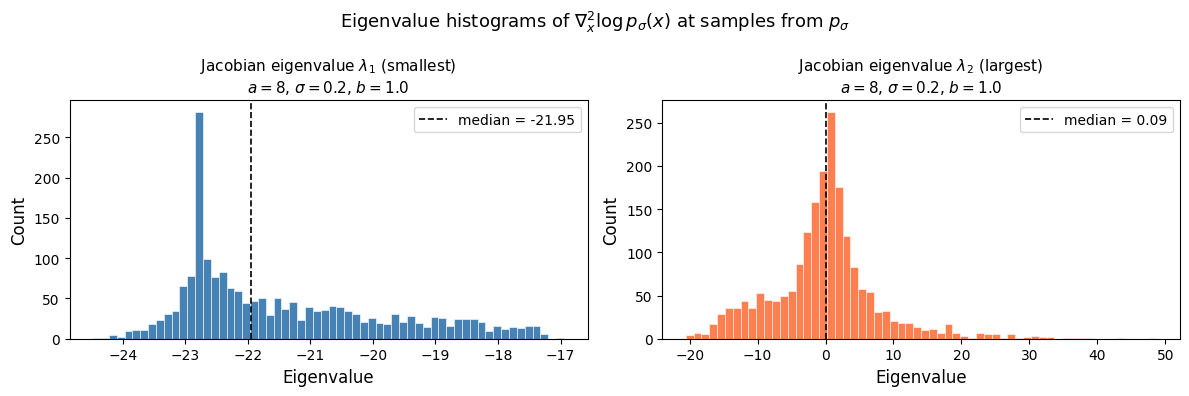

lam1: median=-21.953, mean=-21.406, std=1.646
lam2: median=0.088, mean=-0.153, std=8.035


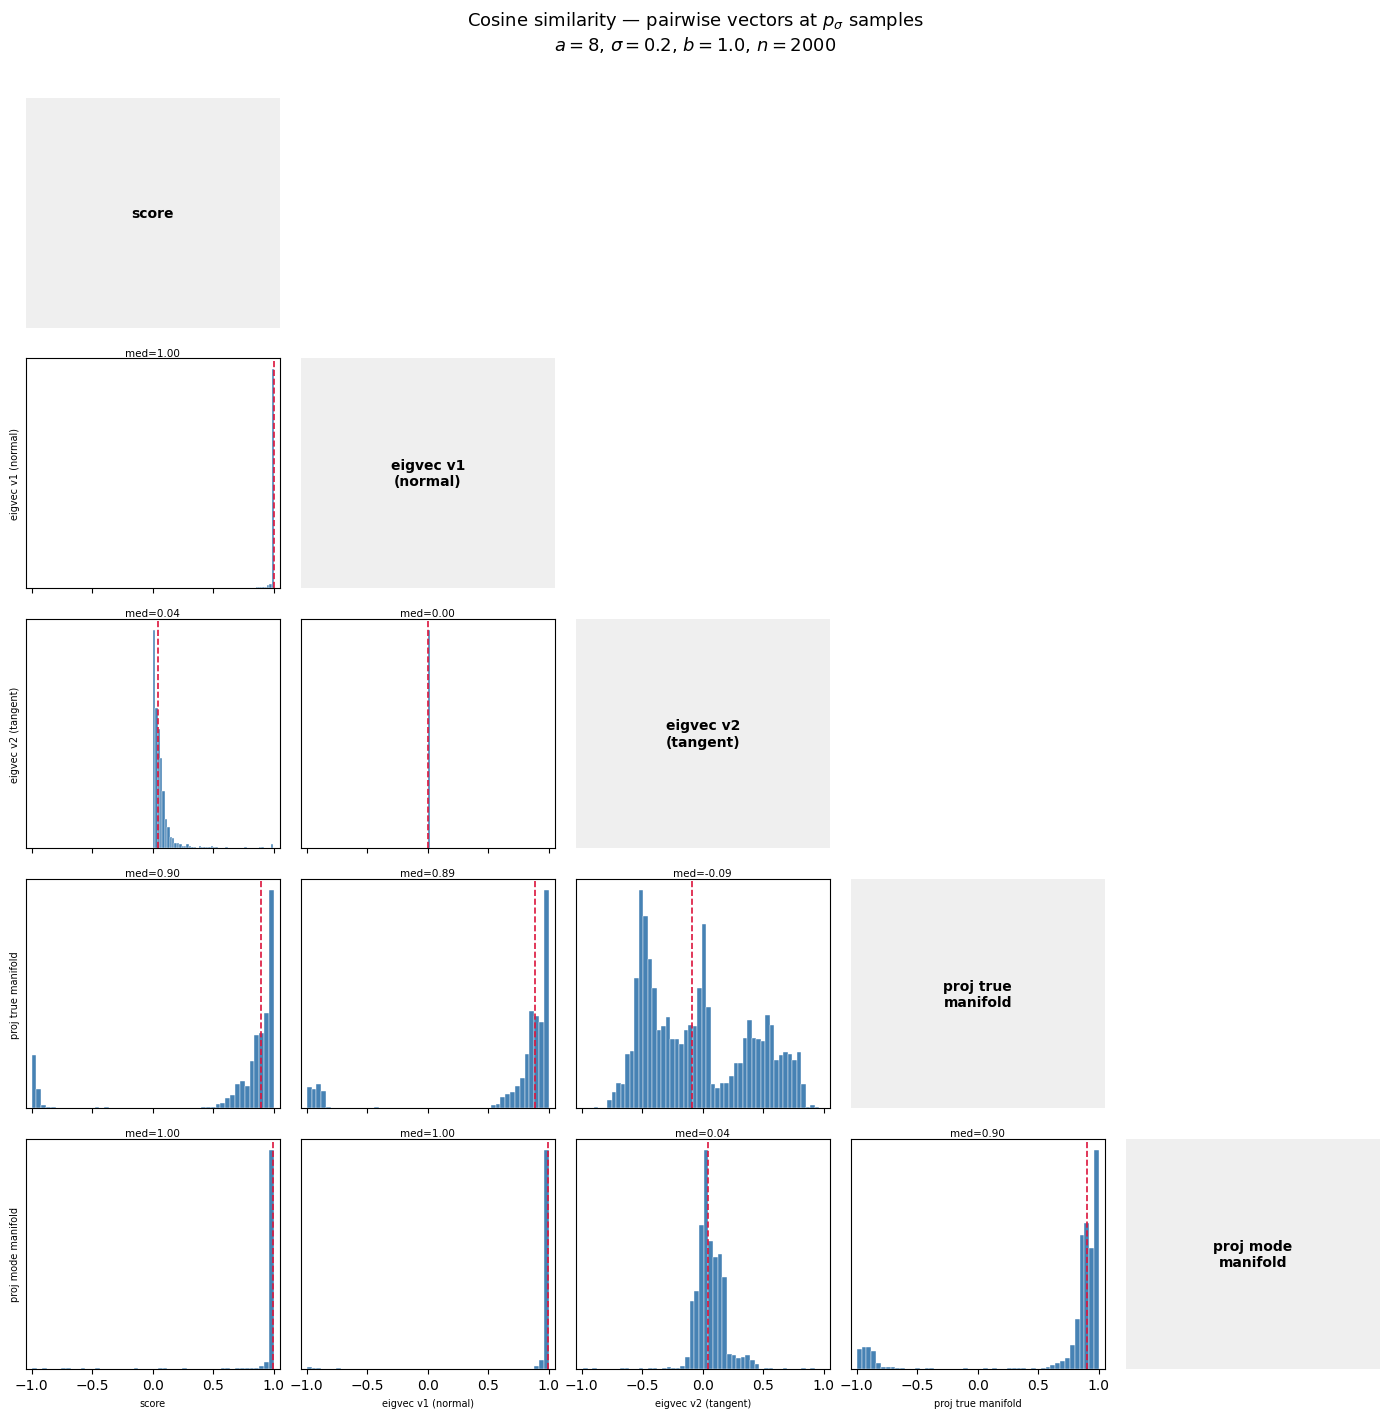

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ── sampling ──────────────────────────────────────────────────────────────────
a, b, sigma, phase = 8, 1.0, 0.2, 0.0
n_samples, num_theta = 2000, 5000

rng = np.random.default_rng(42)
theta_all = np.linspace(0, 2 * np.pi, num_theta)
r_all  = 1 + (b / a) * np.sin(a * theta_all + phase)
dr_all = b * np.cos(a * theta_all + phase)
ds_all = np.sqrt(r_all**2 + dr_all**2)
cdf    = np.cumsum(ds_all); cdf /= cdf[-1]
idx_s  = np.searchsorted(cdf, rng.uniform(0, 1, n_samples))
r_s    = 1 + (b / a) * np.sin(a * theta_all[idx_s] + phase)
x_s    = r_s * np.cos(theta_all[idx_s]) + rng.normal(0, sigma, n_samples)
y_s    = r_s * np.sin(theta_all[idx_s]) + rng.normal(0, sigma, n_samples)

_, x_c, y_c, _ = _wiggly_circle(a, phase, b, num_theta=num_theta)

# ── 1. Eigenvalue histograms ──────────────────────────────────────────────────
lam0 = np.empty(n_samples)
lam1 = np.empty(n_samples)
for i, (xi, yi) in enumerate(zip(x_s, y_s)):
    _, _, eigvals = _score_and_jacobian(xi, yi, x_c, y_c, sigma)
    lam0[i] = eigvals[0]
    lam1[i] = eigvals[1]

fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4))
for ax, lam, label, color in zip(
    axes1,
    [lam0, lam1],
    [r'$\lambda_1$ (smallest)', r'$\lambda_2$ (largest)'],
    ['steelblue', 'coral'],
):
    ax.hist(lam, bins=60, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(np.median(lam), color='k', linestyle='--', linewidth=1.2,
               label=f'median = {np.median(lam):.2f}')
    ax.set_xlabel('Eigenvalue', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'Jacobian eigenvalue {label}\n$a={a}$, $\\sigma={sigma}$, $b={b}$', fontsize=11)
    ax.legend()
fig1.suptitle(r'Eigenvalue histograms of $\nabla_x^2 \log p_\sigma(x)$ at samples from $p_\sigma$',
              fontsize=13)
fig1.tight_layout()
fig1.savefig('plots/09-eigval-histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"lam1: median={np.median(lam0):.3f}, mean={lam0.mean():.3f}, std={lam0.std():.3f}")
print(f"lam2: median={np.median(lam1):.3f}, mean={lam1.mean():.3f}, std={lam1.std():.3f}")

# ── 2. Cosine similarity 5x5 triangular grid ─────────────────────────────────
x_mode_h, y_mode_h = _compute_mode_curve(a, sigma, phase, b)

scores, ev1s, ev2s, pvt, pvm = [], [], [], [], []
for xi, yi in zip(x_s, y_s):
    score, eigvecs, _ = _score_and_jacobian(xi, yi, x_c, y_c, sigma)
    for k in range(2):
        if np.dot(eigvecs[:, k], score) < 0:
            eigvecs[:, k] *= -1
    proj_true, _ = _project(xi, yi, x_c, y_c)
    proj_mode, _ = _project(xi, yi, x_mode_h, y_mode_h)
    scores.append(score)
    ev1s.append(eigvecs[:, 0])
    ev2s.append(eigvecs[:, 1])
    pvt.append(proj_true - np.array([xi, yi]))
    pvm.append(proj_mode - np.array([xi, yi]))

def unit(vecs):
    vecs = np.array(vecs)
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    return vecs / np.where(norms > 1e-12, norms, 1.0)

def cos_sim(u, v):
    return np.einsum('ij,ij->i', u, v)

panel_labels = ["score", "eigvec v1\n(normal)", "eigvec v2\n(tangent)",
                "proj true\nmanifold", "proj mode\nmanifold"]
vecs = [unit(scores), unit(ev1s), unit(ev2s), unit(pvt), unit(pvm)]
n = len(panel_labels)

fig2, axes2 = plt.subplots(n, n, figsize=(14, 14))
for i in range(n):
    for j in range(n):
        ax = axes2[i, j]
        if j > i:
            ax.set_visible(False)
        elif i == j:
            ax.text(0.5, 0.5, panel_labels[i], ha='center', va='center',
                    fontsize=10, fontweight='bold', transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_facecolor('#efefef')
            for spine in ax.spines.values():
                spine.set_visible(False)
        else:
            cs = cos_sim(vecs[i], vecs[j])
            ax.hist(cs, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
            ax.axvline(np.median(cs), color='crimson', lw=1.2, linestyle='--')
            ax.set_xlim(-1.05, 1.05)
            ax.set_yticks([])
            ax.set_title(f'med={np.median(cs):.2f}', fontsize=7.5, pad=2)
            if i == n - 1:
                ax.set_xlabel(panel_labels[j].replace('\n', ' '), fontsize=7)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(panel_labels[i].replace('\n', ' '), fontsize=7)

fig2.suptitle(
    f'Cosine similarity — pairwise vectors at $p_\\sigma$ samples\n'
    f'$a={a}$, $\\sigma={sigma}$, $b={b}$, $n={n_samples}$',
    fontsize=13, y=1.01
)
fig2.tight_layout()
fig2.savefig('plots/10-cosine-similarity.png', dpi=150, bbox_inches='tight')
plt.show()